# Sleep Stage Classification Pipeline
**Preprocessing**: Feature engineering (aggregation + temporal features)
**Model**: Improved TCN with residual blocks

Each 480-row epoch is aggregated into statistical features, then **SEQ_LEN** consecutive epochs form a sequence fed into the TCN.

In [ ]:
import numpy as np
import pandas as pd
import glob
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, GlobalAveragePooling1D,
    Dense, BatchNormalization, Dropout, Add
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

print(f'TensorFlow version: {tf.__version__}')

2026-04-04 06:25:37.407173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775283937.627264      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775283937.693407      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775283938.201352      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775283938.201415      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775283938.201419      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


## Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
TRAIN_PATH = "/kaggle/input/competitions/super-ai-engineer-ss-6-sleep-stage-classification/train/train/train*.csv"
TEST_PATH  = "/kaggle/input/competitions/super-ai-engineer-ss-6-sleep-stage-classification/test_segment/test_segment/*/*.csv"
SAMPLE_SUB = "/kaggle/input/competitions/super-ai-engineer-ss-6-sleep-stage-classification/sample_submission.csv"

# ── Hyper-parameters ───────────────────────────────────────────────────────────
EPOCH_SIZE  = 480        # rows per epoch (same as both notebooks)
SEQ_LEN     = 5          # number of consecutive epochs fed to the TCN
NUM_CLASSES = 5
BATCH_SIZE  = 64
MAX_EPOCHS  = 200
LR          = 0.01

# ── Label mapping (from notebook 1) ───────────────────────────────────────────
STAGE_MAP    = {"W": 0, "R": 1, "N1": 2, "N2": 3, "N3": 4}
INV_STAGE    = {v: k for k, v in STAGE_MAP.items()}

## 1 · Helper Functions (from `602263-sleepstage.ipynb`)

In [ ]:
def calc_cv(x):
    """Coefficient of Variation – measures relative spread."""
    m = np.mean(x)
    return np.std(x) / m if m != 0 else 0


def get_mode(x):
    """Mode of a series – majority label within an epoch."""
    m = x.mode()
    return m[0] if not m.empty else np.nan


# Aggregation spec (shared between train and test, minus Sleep_Stage)
SIGNAL_AGGS = {
    'BVP':     ['mean', 'std', 'min', 'max', 'skew'],
    'ACC_mag': ['mean', 'std', 'max'],
    'TEMP':    ['mean', 'std'],
    'EDA':     ['mean', 'std', 'max'],
    'HR':      ['mean', 'std', 'min', 'max', calc_cv],
    'IBI':     ['mean', 'std', calc_cv],
}


def _col_name(col, func):
    return f"{col}_{func}" if isinstance(func, str) else f"{col}_{func.__name__}"


def process_train_file(file_path):
    """Aggregate a training CSV into one row per 480-row epoch."""
    df = pd.read_csv(file_path)
    df['ACC_mag']  = np.sqrt(df['ACC_X']**2 + df['ACC_Y']**2 + df['ACC_Z']**2)
    df['epoch_id'] = np.arange(len(df)) // EPOCH_SIZE

    aggs = {**SIGNAL_AGGS, 'Sleep_Stage': [get_mode]}
    epoch_df = df.groupby('epoch_id').agg(aggs)
    epoch_df.columns = [_col_name(*c) for c in epoch_df.columns.values]
    epoch_df.rename(columns={'Sleep_Stage_get_mode': 'Sleep_Stage'}, inplace=True)
    epoch_df['file_id'] = os.path.basename(file_path)
    epoch_df = epoch_df.reset_index()          # keep epoch_id as column
    return epoch_df


def process_test_file(file_path):
    """Aggregate a single test-segment CSV into one feature row."""
    df = pd.read_csv(file_path)
    df['ACC_mag'] = np.sqrt(df['ACC_X']**2 + df['ACC_Y']**2 + df['ACC_Z']**2)

    row_data = {}
    for col, funcs in SIGNAL_AGGS.items():
        for func in funcs:
            val = df[col].agg(func) if isinstance(func, str) else func(df[col])
            row_data[_col_name(col, func)] = val

    folder_name = os.path.basename(os.path.dirname(file_path))
    file_name   = os.path.basename(file_path).replace('.csv', '')
    row_data['id']      = file_name
    row_data['file_id'] = folder_name
    return pd.DataFrame([row_data])


def add_temporal_features(df, group_col='file_id'):
    """Add lag-1, lag-2, lead-1, rolling-mean-5, rolling-std-5 for every feature."""
    df = df.copy()
    exclude = {'Sleep_Stage', 'Sleep_Stage_Encoded', 'file_id', 'id', 'epoch_id'}
    features = [c for c in df.columns if c not in exclude]

    for f in features:
        df[f'{f}_lag1']  = df.groupby(group_col)[f].shift(1)
        df[f'{f}_lag2']  = df.groupby(group_col)[f].shift(2)
        df[f'{f}_lead1'] = df.groupby(group_col)[f].shift(-1)

    df.bfill(inplace=True)
    df.ffill(inplace=True)

    for f in features:
        df[f'{f}_rolling_mean_5'] = df.groupby(group_col)[f].transform(
            lambda x: x.rolling(5, min_periods=1).mean()
        )
        df[f'{f}_rolling_std_5'] = df.groupby(group_col)[f].transform(
            lambda x: x.rolling(5, min_periods=1).std()
        )

    df.fillna(0, inplace=True)
    return df

## 2 · Load & Preprocess Training Data

In [ ]:
train_files = sorted(glob.glob(TRAIN_PATH))
print(f"Found {len(train_files)} training files")

print("Aggregating train files...")
train_dfs = [process_train_file(f) for f in tqdm(train_files)]
train_df  = pd.concat(train_dfs, ignore_index=True)
train_df.fillna(train_df.mean(numeric_only=True), inplace=True)
print(f"Raw epoch table shape: {train_df.shape}")

Found 83 training files
Aggregating train files...


100%|██████████| 83/83 [01:43<00:00,  1.25s/it]

Raw epoch table shape: (66745, 24)


In [ ]:
print("Adding temporal features to train data...")
train_df = add_temporal_features(train_df, group_col='file_id')

# Encode labels
train_df['Sleep_Stage_Encoded'] = train_df['Sleep_Stage'].map(STAGE_MAP)

# Feature columns (everything except metadata & label columns)
EXCLUDE_COLS  = {'Sleep_Stage', 'Sleep_Stage_Encoded', 'file_id', 'epoch_id'}
FEATURE_COLS  = [c for c in train_df.columns if c not in EXCLUDE_COLS]

print(f"Feature count : {len(FEATURE_COLS)}")
print(f"Train epochs  : {len(train_df)}")
print(f"Label distribution:\n{train_df['Sleep_Stage'].value_counts()}")

Adding temporal features to train data...
Feature count : 126
Train epochs  : 66745
Label distribution:
Sleep_Stage
N2    33786
W     15828
N1     7753
R      7033
N3     2345
Name: count, dtype: int64


## 3 · Build Sequences for TCN

For each epoch **i** within a file, we take the **SEQ_LEN** consecutive epochs ending at **i** as a sequence (zero-padded at the start when **i < SEQ_LEN**). The label is the Sleep_Stage of epoch **i**.

In [ ]:
def make_train_sequences(df, feature_cols, label_col, group_col, seq_len):
    """
    Returns
    -------
    X : np.ndarray  shape (n_samples, seq_len, n_features)
    y : np.ndarray  shape (n_samples,)
    """
    X_list, y_list = [], []
    n_feat = len(feature_cols)

    for _, group in tqdm(df.groupby(group_col), desc="Building sequences"):
        group   = group.sort_values('epoch_id').reset_index(drop=True)
        feats   = group[feature_cols].values.astype(np.float32)  # (n_epochs, n_feat)
        labels  = group[label_col].values

        for i in range(len(feats)):
            start = max(0, i - seq_len + 1)
            seq   = feats[start : i + 1]                         # (actual_len, n_feat)
            if len(seq) < seq_len:
                pad = np.zeros((seq_len - len(seq), n_feat), dtype=np.float32)
                seq = np.vstack([pad, seq])
            X_list.append(seq)
            y_list.append(labels[i])

    return np.array(X_list, dtype=np.float32), np.array(y_list)


X_train, y_train = make_train_sequences(
    train_df, FEATURE_COLS, 'Sleep_Stage_Encoded', 'file_id', SEQ_LEN
)
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

from collections import Counter
print(f"Label counts: {Counter(y_train)}")

Building sequences: 100%|██████████| 83/83 [00:00<00:00, 137.25it/s]


X_train : (66745, 5, 126)
y_train : (66745,)
Label counts: Counter({np.int64(3): 33786, np.int64(0): 15828, np.int64(2): 7753, np.int64(1): 7033, np.int64(4): 2345})


## 4 · Weighted F1 Metric (from `final-hack-iot-tcnlstm-cnn.ipynb`)

In [ ]:
def f1_weighted(y_true, y_pred):
    num_classes    = K.int_shape(y_pred)[-1]
    y_pred_labels  = K.argmax(y_pred, axis=-1)

    f1_scores, weights = [], []
    for i in range(num_classes):
        true_mask = K.cast(K.equal(y_true, i), 'float64')
        pred_mask = K.cast(K.equal(y_pred_labels, i), 'float64')

        tp = K.sum(true_mask * pred_mask)
        fp = K.sum(pred_mask) - tp
        fn = K.sum(true_mask) - tp

        precision = tp / (tp + fp + K.epsilon())
        recall    = tp / (tp + fn + K.epsilon())
        f1        = 2 * precision * recall / (precision + recall + K.epsilon())

        f1_scores.append(f1)
        weights.append(K.sum(true_mask))

    f1_scores = K.stack(f1_scores)
    weights   = K.stack(weights)
    weights  /= K.sum(weights) + K.epsilon()
    return K.sum(f1_scores * weights)

## 5 · Improved TCN Model (from `final-hack-iot-tcnlstm-cnn.ipynb`)

In [ ]:
def residual_block(x, filters, dilation_rate):
    """TCN residual block with dilated causal convolutions."""
    shortcut = x
    x = Conv1D(filters, 3, padding='same', activation='relu',
               dilation_rate=dilation_rate, kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Conv1D(filters, 3, padding='same', activation='relu',
               dilation_rate=dilation_rate, kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Add()([shortcut, x])   # residual connection
    return x


def build_tcn_model(input_shape, num_classes):
    """
    Improved TCN from final-hack-iot-tcnlstm-cnn.ipynb.
    input_shape : (seq_len, n_features)
    """
    inputs = Input(shape=input_shape)

    # Entry block – project to 64 channels
    x = Conv1D(64, 3, padding='same', activation='relu',
               dilation_rate=1, kernel_regularizer=l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    # Residual blocks with increasing dilation rates
    x = residual_block(x, 64, dilation_rate=2)
    x = residual_block(x, 64, dilation_rate=4)
    x = residual_block(x, 64, dilation_rate=8)

    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)


input_shape = (SEQ_LEN, len(FEATURE_COLS))
model = build_tcn_model(input_shape, num_classes=NUM_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=[f1_weighted]
)
model.summary()

I0000 00:00:1775284070.620747      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5, 126)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 5, 64)     │     24,256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 5, 64)     │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 5, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 5, 64)     │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 64)     │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 5, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 5, 64)     │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 64)     │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 5, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 5, 64)     │          0 │ dropout[0][0],    │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 5, 64)     │     12,352 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 64)     │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 5, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 5, 64)     │     12,352 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 64)     │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 5, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 5, 64)     │          0 │ add[0][0],        │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 5, 64)     │     12,352 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 64)     │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 100,485 (392.52 KB)

 Trainable params: 99,589 (389.02 KB)

 Non-trainable params: 896 (3.50 KB)

## 6 · Train

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_f1_weighted', mode='max',
        patience=15, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_f1_weighted', mode='max',
        factor=0.5, patience=5, min_lr=1e-5, verbose=1
    ),
    ModelCheckpoint(
        'best_tcn_pipeline.keras',
        monitor='val_f1_weighted', mode='max',
        save_best_only=True, verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    epochs=MAX_EPOCHS,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/200


I0000 00:00:1775284078.199828     123 service.cc:152] XLA service 0x79d824002630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775284078.199861     123 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775284079.346517     123 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775284086.432676     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_f1_weighted improved from -inf to 0.46083, saving model to best_tcn_pipeline.keras
835/835 - 27s - 33ms/step - f1_weighted: 0.4744 - loss: 1.4299 - val_f1_weighted: 0.4608 - val_loss: 1.3626 - learning_rate: 0.0100
Epoch 2/200

Epoch 2: val_f1_weighted did not improve from 0.46083
835/835 - 4s - 5ms/step - f1_weighted: 0.4805 - loss: 1.2520 - val_f1_weighted: 0.4337 - val_loss: 1.4814 - learning_rate: 0.0100
Epoch 3/200

Epoch 3: val_f1_weighted did not improve from 0.46083
835/835 - 4s - 5ms/step - f1_weighted: 0.4818 - loss: 1.2266 - val_f1_weighted: 0.4472 - val_loss: 1.4262 - learning_rate: 0.0100
Epoch 4/200

Epoch 4: val_f1_weighted did not improve from 0.46083
835/835 - 4s - 5ms/step - f1_weighted: 0.4763 - loss: 1.2296 - val_f1_weighted: 0.4364 - val_loss: 1.5533 - learning_rate: 0.0100
Epoch 5/200

Epoch 5: val_f1_weighted did not improve from 0.46083
835/835 - 4s - 5ms/step - f1_weighted: 0.4803 - loss: 1.2157 - val_f1_weighted: 0.4537 - val_loss: 1.4943 - learn

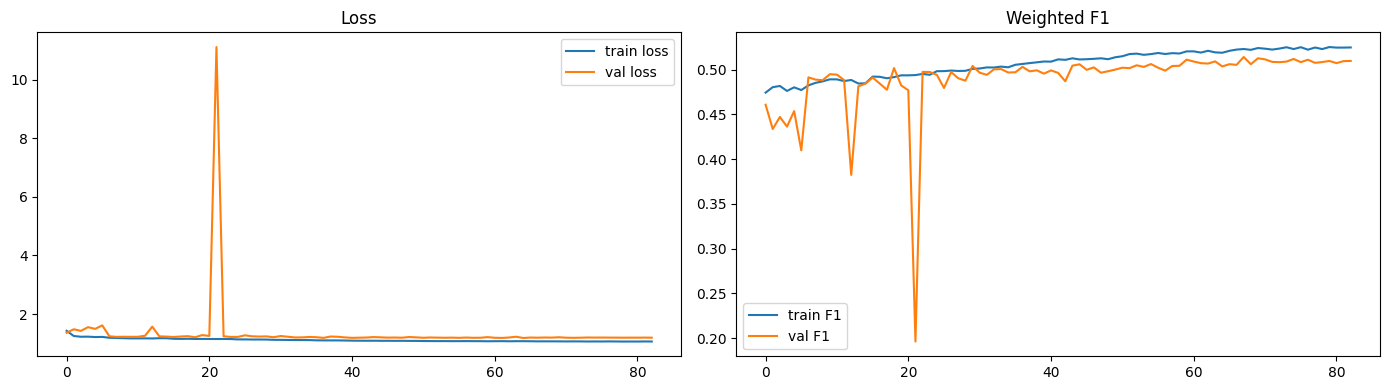

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['f1_weighted'],     label='train F1')
axes[1].plot(history.history['val_f1_weighted'], label='val F1')
axes[1].set_title('Weighted F1')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7 · Load & Preprocess Test Data

In [ ]:
test_files = sorted(glob.glob(TEST_PATH))
print(f"Found {len(test_files)} test files")

print("Aggregating test files...")
test_dfs = [process_test_file(f) for f in tqdm(test_files)]
test_df  = pd.concat(test_dfs, ignore_index=True)
test_df.fillna(test_df.mean(numeric_only=True), inplace=True)
print(f"Raw test table shape: {test_df.shape}")

Found 7832 test files
Aggregating test files...


100%|██████████| 7832/7832 [01:37<00:00, 80.68it/s]


Raw test table shape: (7832, 23)


In [ ]:
print("Adding temporal features to test data...")
test_df = add_temporal_features(test_df, group_col='file_id')
test_df.fillna(0, inplace=True)

# Use only features seen during training
TEST_FEATURE_COLS = [c for c in FEATURE_COLS if c in test_df.columns]
missing = set(FEATURE_COLS) - set(TEST_FEATURE_COLS)
if missing:
    print(f"Warning: {len(missing)} feature(s) missing in test data – filling with 0")
    for col in missing:
        test_df[col] = 0.0
    TEST_FEATURE_COLS = FEATURE_COLS   # now all present

print(f"Test data ready: {test_df.shape}")

Adding temporal features to test data...
Test data ready: (7832, 128)


## 8 · Build Test Sequences

In [ ]:
def make_test_sequences(df, feature_cols, id_col, group_col, seq_len):
    """
    Returns
    -------
    X   : np.ndarray  shape (n_samples, seq_len, n_features)
    ids : list        length n_samples
    """
    X_list, id_list = [], []
    n_feat = len(feature_cols)

    for _, group in tqdm(df.groupby(group_col), desc="Building test sequences"):
        group = group.sort_values(id_col).reset_index(drop=True)
        feats = group[feature_cols].values.astype(np.float32)
        ids   = group[id_col].values

        for i in range(len(feats)):
            start = max(0, i - seq_len + 1)
            seq   = feats[start : i + 1]
            if len(seq) < seq_len:
                pad = np.zeros((seq_len - len(seq), n_feat), dtype=np.float32)
                seq = np.vstack([pad, seq])
            X_list.append(seq)
            id_list.append(ids[i])

    return np.array(X_list, dtype=np.float32), id_list


X_test, test_ids = make_test_sequences(
    test_df, TEST_FEATURE_COLS, 'id', 'file_id', SEQ_LEN
)
print(f"X_test  : {X_test.shape}")
print(f"# ids   : {len(test_ids)}")

Building test sequences: 100%|██████████| 10/10 [00:00<00:00, 181.29it/s]

X_test  : (7832, 5, 126)
# ids   : 7832


## 9 · Predict & Create Submission

In [ ]:
print("Predicting...")
probs            = model.predict(X_test, batch_size=256, verbose=1)
predicted_class  = np.argmax(probs, axis=1)
predicted_labels = [INV_STAGE[c] for c in predicted_class]

pred_df = pd.DataFrame({'id': test_ids, 'labels': predicted_labels})
print("\nPrediction distribution:")
print(pred_df['labels'].value_counts())

Predicting...
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step

Prediction distribution:
labels
N2    5821
W     1965
R       43
N1       3
Name: count, dtype: int64


In [ ]:
# Align with sample submission order
sample_sub = pd.read_csv(SAMPLE_SUB)
submission = sample_sub[['id']].merge(pred_df, on='id', how='left')
submission['labels'] = submission['labels'].fillna('W')   # fallback

submission.to_csv('sleep_tcnn_prepro_submission.csv', index=False)
print("Saved submission.csv")
print(submission.head(10))

Saved submission.csv
              id labels
0  test001_00000      W
1  test001_00001      W
2  test001_00002      W
3  test001_00003      W
4  test001_00004      W
5  test001_00005      W
6  test001_00006      W
7  test001_00007      W
8  test001_00008     N2
9  test001_00009     N2
